<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Simon_EvenMansour_Break.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simon's Algorithm — Breaking the Even–Mansour Cipher on Aer

The third quantum primitive in this repo, and the one with the most surprising security punch.
**Shor** is exponential against public-key crypto; **Grover** is quadratic against symmetric crypto;
**Simon** is *exponential* against certain symmetric **constructions** — it recovers a secret key in
$O(n)$ queries where classical search needs $O(2^{n/2})$.

We demonstrate the **Kuwakado–Morii** key-recovery attack on the **Even–Mansour** cipher
$$E_{k_1,k_2}(x) = P(x \oplus k_1)\oplus k_2,\qquad P \text{ a public permutation,}$$
which is classically secure to ~$2^{n/2}$ but falls to Simon in linear time.

## ⚠️ Honest framing: the superposition-query (Q2) model

This attack lives in the **Q2 model**, where the adversary may query the cipher *on quantum
superpositions of plaintexts* — i.e. evaluate $\sum_x|x\rangle \mapsto \sum_x|E(x)\rangle$. Real
attackers get only **classical** access (the **Q1** model), so Even–Mansour-via-Simon is a
*structural* warning about fragile constructions in a quantum world, **not** a break of any deployed
system. (The advanced "offline-Simon" technique, Bonnetain et al. 2019, moves some of these attacks
into Q1 by combining Simon with Grover.)

**Scope on Aer.** The oracle needs three $n$-qubit registers (input, output, and a scratch register
to evaluate the public permutation twice), so the circuit is **3n qubits**. The practical ceiling is
**n = 9 (27 qubits)**; n = 10 needs a 16 GB statevector. Default below is n = 8 for a smooth run.

In [1]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.1 MB/s eta 0:00:00


## How Simon works (the period-finding core)

Given $f:\{0,1\}^n\to\{0,1\}^n$ promised to satisfy $f(x)=f(y)\iff y=x\oplus s$ for a hidden
$s\neq 0$, Simon finds $s$. The circuit is just **H — oracle — H — measure**:
1. $H^{\otimes n}$ on the input makes a uniform superposition.
2. The oracle writes $f(x)$ into an output register, entangling input with $f$.
3. A second $H^{\otimes n}$ causes interference: **every measurement $y$ satisfies $y\cdot s=0 \pmod 2$.**
4. Collect $n-1$ independent such $y$, solve the linear system over $\mathrm{GF}(2)$, and the
   one-dimensional null space gives $s$.

For Even–Mansour we set $f(x)=E(x)\oplus P(x)$. Since
$f(x\oplus k_1)=P(x)\oplus k_2\oplus P(x\oplus k_1)=f(x)$, the hidden period is **$s=k_1$** — so
Simon hands us the first key directly.

## 1. The toy cipher: a public permutation $P$, secret keys $k_1,k_2$

$P$ is a full-width nonlinear permutation built from cheap reversible gates (Toffoli for
nonlinearity + CNOT for diffusion, a few rounds) so it stays fast at $n=8$–$9$. We define it once,
both as a classical table (for verification and the public side of the attack) and as the identical
quantum sub-circuit (for the oracle).

In [2]:
import numpy as np, time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from collections import Counter

# ---- choose size ----
N      = 8          # default. Tested max on Aer: 9 (27 qubits, ~2-3 min, ~2 GB). 10 needs ~16 GB.
ROUNDS = 4          # mixing rounds in the public permutation P
k1     = (1 << N) - 3      # secret key 1 (the period Simon will recover)
k2     = 5                # secret key 2

# public permutation P, defined identically as classical fn and quantum circuit
def P_classical(v):
    b = [(v >> i) & 1 for i in range(N)]
    for _ in range(ROUNDS):
        for i in range(N): b[(i+2) % N] ^= b[i] & b[(i+1) % N]   # nonlinear (Toffoli)
        for i in range(N): b[(i+1) % N] ^= b[i]                  # diffusion (CNOT)
    return sum(bit << i for i, bit in enumerate(b))

def P_subcircuit(qc, reg):
    for _ in range(ROUNDS):
        for i in range(N): qc.ccx(reg[i], reg[(i+1) % N], reg[(i+2) % N])
        for i in range(N): qc.cx(reg[i], reg[(i+1) % N])

P = [P_classical(v) for v in range(2**N)]
assert sorted(P) == list(range(2**N)), "P must be a permutation"
def E(x): return P[x ^ k1] ^ k2          # Even-Mansour cipher
def f(x): return E(x) ^ P[x]             # Simon function (period k1)

# verify the promise: f is (essentially) 2-to-1 with the single hidden period k1
buckets = Counter(f(x) for x in range(2**N))
periods = [s for s in range(1, 2**N) if all(f(x) == f(x ^ s) for x in range(2**N))]
print(f"n = {N}  ->  {3*N}-qubit circuit")
print(f"secret keys (hidden from the attack):  k1 = {k1:0{N}b}  k2 = {k2:0{N}b}")
print(f"hidden period(s) of f: {periods}   (Simon should return {k1})")
print(f"fraction of digests with exactly 2 preimages: "
      f"{sum(1 for c in buckets.values() if c==2)/len(buckets):.2f} "
      f"(random P has a few accidental collisions; Simon is robust to them)")

n = 8  ->  24-qubit circuit
secret keys (hidden from the attack):  k1 = 11111101  k2 = 00000101
hidden period(s) of f: [253]   (Simon should return 253)
fraction of digests with exactly 2 preimages: 0.70 (random P has a few accidental collisions; Simon is robust to them)


## 2. The reversible Simon oracle ($3n$ qubits)

The oracle maps $|x\rangle|0\rangle_{\text{out}} \to |x\rangle|f(x)\rangle_{\text{out}}$ with
$f(x)=P(x)\oplus E(x)$. Because $f$ uses $P$ at two points ($x$ and $x\oplus k_1$), a scratch
register evaluates $P$, XORs the result into the output, and is uncomputed back to $0$ — twice.

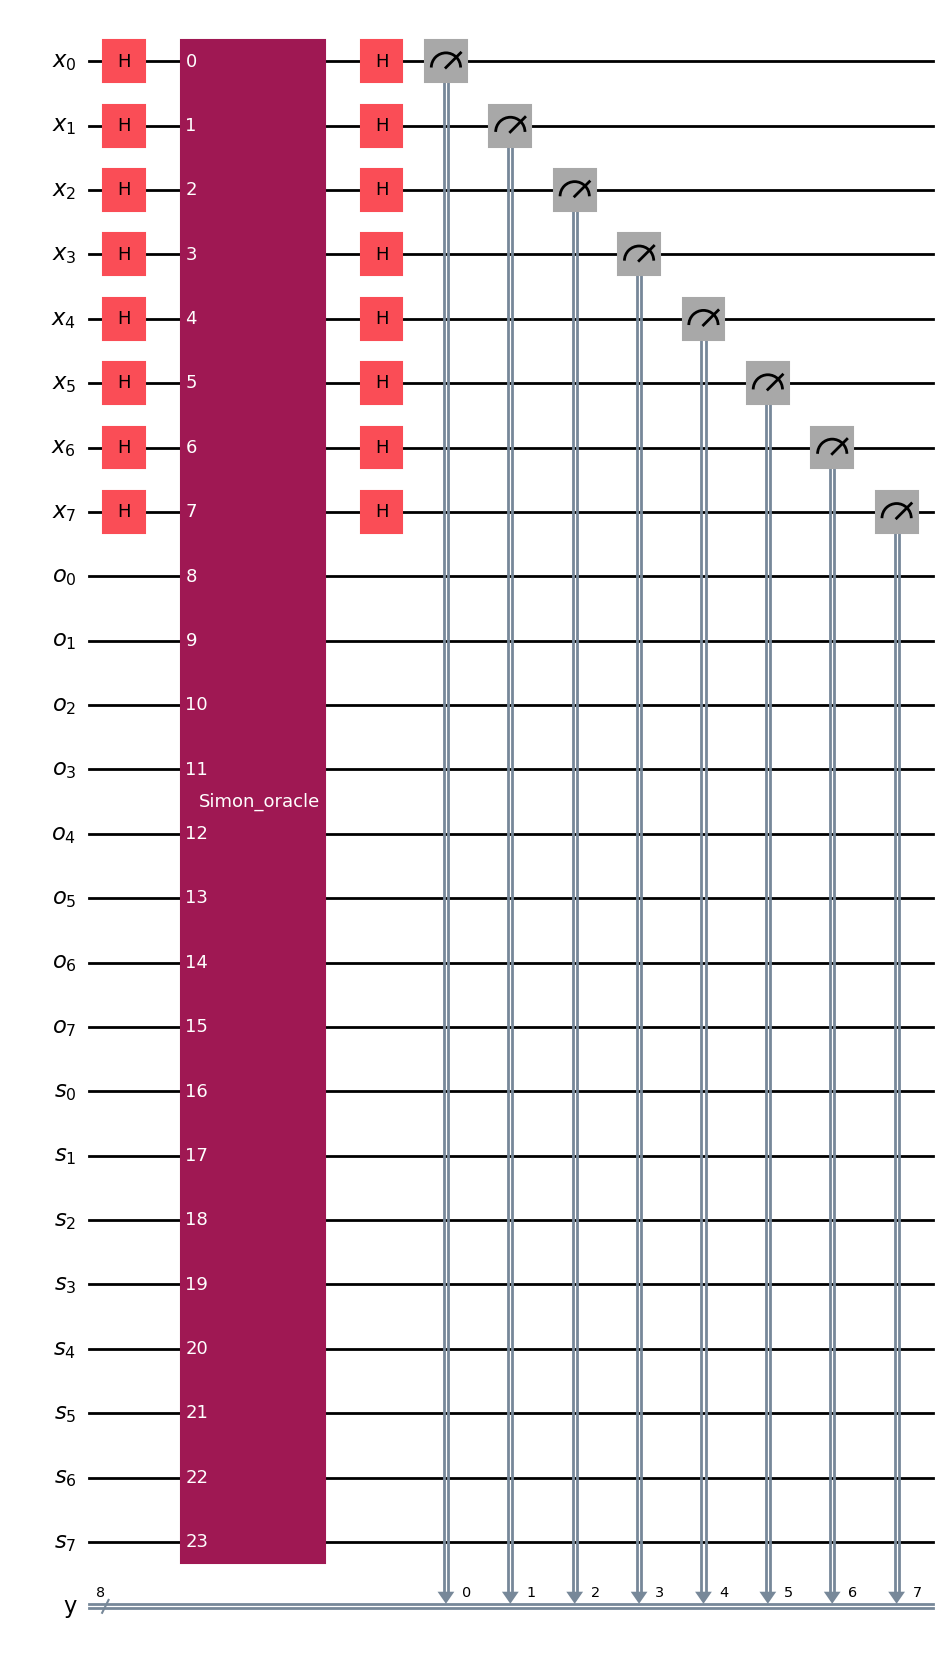

In [3]:
def simon_oracle():
    x = QuantumRegister(N, 'x'); out = QuantumRegister(N, 'o'); s = QuantumRegister(N, 's')
    qc = QuantumCircuit(x, out, s, name="Simon_oracle")

    # --- term 1:  out ^= P(x) ---
    for i in range(N): qc.cx(x[i], s[i])          # s = x
    P_subcircuit(qc, s)                            # s = P(x)
    for i in range(N): qc.cx(s[i], out[i])         # out ^= P(x)
    inv = QuantumCircuit(s); P_subcircuit(inv, s)  # uncompute s -> x
    qc.compose(inv.inverse(), qubits=s[:], inplace=True)
    for i in range(N): qc.cx(x[i], s[i])           # s = 0

    # --- term 2:  out ^= E(x) = P(x^k1)^k2 ---
    for i in range(N): qc.cx(x[i], s[i])           # s = x
    for i in range(N):
        if (k1 >> i) & 1: qc.x(s[i])              # s = x ^ k1
    P_subcircuit(qc, s)                            # s = P(x^k1)
    for i in range(N):
        if (k2 >> i) & 1: qc.x(s[i])              # s = E(x)
    for i in range(N): qc.cx(s[i], out[i])         # out ^= E(x)
    for i in range(N):
        if (k2 >> i) & 1: qc.x(s[i])
    inv2 = QuantumCircuit(s); P_subcircuit(inv2, s)
    qc.compose(inv2.inverse(), qubits=s[:], inplace=True)
    for i in range(N):
        if (k1 >> i) & 1: qc.x(s[i])
    for i in range(N): qc.cx(x[i], s[i])           # s = 0
    return qc

x = QuantumRegister(N, 'x'); out = QuantumRegister(N, 'o'); s = QuantumRegister(N, 's')
cl = ClassicalRegister(N, 'y')
simon = QuantumCircuit(x, out, s, cl)
simon.h(x)
simon.append(simon_oracle().to_gate(), x[:] + out[:] + s[:])
simon.h(x)
simon.measure(x, cl)
simon.draw('mpl', fold=-1)

## 3. Run, collect equations, and recover $k_1$ (the period)

Each shot yields a $y$ with $y\cdot k_1=0$. We gather many, reduce over $\mathrm{GF}(2)$, and the
non-trivial null-space vector is $k_1$.

In [4]:
sim = AerSimulator(method='statevector')
t0 = time.time()
tqc = transpile(simon, sim)              # decompose the oracle gate (cheap: CCX/CX only)
counts = sim.run(tqc, shots=6*N).result().get_counts()
print(f"ran {6*N} shots in {time.time()-t0:.1f}s; {len(counts)} distinct equations y (each with y . k1 = 0)\n")

# Gaussian elimination over GF(2) -> null space
rows = [[int(c) for c in bs[::-1]] for bs in counts]   # little-endian bit vectors
mat = [r[:] for r in rows]; pivots = []; r = 0
for c in range(N):
    piv = next((i for i in range(r, len(mat)) if mat[i][c] == 1), None)
    if piv is None: continue
    mat[r], mat[piv] = mat[piv], mat[r]
    for i in range(len(mat)):
        if i != r and mat[i][c] == 1:
            mat[i] = [a ^ b for a, b in zip(mat[i], mat[r])]
    pivots.append(c); r += 1
free = [c for c in range(N) if c not in pivots]

recovered = None
for fcol in free:
    vec = [0]*N; vec[fcol] = 1
    for i, pc in enumerate(pivots): vec[pc] = mat[i][fcol]
    val = sum(b << i for i, b in enumerate(vec))
    if val and f(0) == f(val):       # verify it's a genuine period
        recovered = val; break

print(f"recovered period  k1 = {recovered:0{N}b} ({recovered})   true k1 = {k1:0{N}b}")
print(f"Simon recovered the first Even-Mansour key: {recovered == k1}")

ran 48 shots in 44.0s; 43 distinct equations y (each with y . k1 = 0)

recovered period  k1 = 11111101 (253)   true k1 = 11111101
Simon recovered the first Even-Mansour key: True


## 4. Finish the break — recover $k_2$

With $k_1$ known, one classical cipher query gives $k_2$: since $E(0)=P(k_1)\oplus k_2$,
$$k_2 = E(0)\oplus P(k_1).$$

In [5]:
k2_recovered = E(0) ^ P[recovered]      # E(0) is one classical query; P(k1) is public
print(f"E(0) = {E(0):0{N}b}   P(k1) = {P[recovered]:0{N}b}")
print(f"recovered k2 = {k2_recovered:0{N}b} ({k2_recovered})   true k2 = {k2:0{N}b}")
print()
print("FULL KEY RECOVERED" if (recovered==k1 and k2_recovered==k2) else "mismatch")
print(f"  k1 = {recovered:0{N}b}")
print(f"  k2 = {k2_recovered:0{N}b}")
print(f"\nQuery cost: ~{6*N} superposition queries (Simon) + 1 classical query, vs "
      f"~2^{N//2} classically. Exponential speedup.")

E(0) = 10000110   P(k1) = 10000011
recovered k2 = 00000101 (5)   true k2 = 00000101

FULL KEY RECOVERED
  k1 = 11111101
  k2 = 00000101

Query cost: ~48 superposition queries (Simon) + 1 classical query, vs ~2^4 classically. Exponential speedup.


## 5. Scaling and the Aer wall

In [6]:
print(f"{'n (key bits)':>13}{'qubits (3n)':>13}{'classical 2^(n/2)':>20}{'Simon queries':>16}{'on Aer?':>10}")
for n in [N, 9, 10, 64]:
    q = 3*n
    feasible = 'yes' if q <= 27 else ('16GB+' if n==10 else 'NO')
    print(f"{n:>13}{q:>13}{('2^%.0f'%(n/2)):>20}{('~%d'%(6*n)):>16}{feasible:>10}")
print("\nSimon: EXPONENTIAL speedup, but only against structured constructions (Even-Mansour,")
print("3-round Feistel, CBC-MAC/GCM...) AND only in the Q2 superposition-query model.")
print("Real ciphers in the realistic Q1 model are unaffected by the basic attack.")

 n (key bits)  qubits (3n)   classical 2^(n/2)   Simon queries   on Aer?
            8           24                 2^4             ~48       yes
            9           27                 2^4             ~54       yes
           10           30                 2^5             ~60     16GB+
           64          192                2^32            ~384        NO

Simon: EXPONENTIAL speedup, but only against structured constructions (Even-Mansour,
3-round Feistel, CBC-MAC/GCM...) AND only in the Q2 superposition-query model.
Real ciphers in the realistic Q1 model are unaffected by the basic attack.


### Notes

- **What Simon adds to the repo's threat picture.** Shor (exponential, public-key, realistic model)
  and Grover (quadratic, symmetric, realistic model) are joined by Simon (exponential, symmetric, but
  only for special constructions in the superposition-query model). The lesson is that *structure*,
  not key length, is what Simon exploits.
- **Other Simon targets** you can adapt this oracle to: the 3-round Feistel / Luby–Rackoff
  distinguisher, and MAC forgeries (CBC-MAC, PMAC, GMAC/GCM) — all via a periodic $f$ built from the
  primitive.
- **Push n to 9** by setting `N = 9` (27 qubits, ~2–3 min, ~2 GB RAM). `N = 10` needs ~16 GB and is
  beyond typical Aer/Colab — that memory wall is the same one protecting real ciphers, scaled down.